
# Fraudulent E-Commerce Transaction Detection Using XGBoost — Revised Analysis

Notebook revisi ini memperbaiki beberapa kelemahan eksperimen sebelumnya:

1. menghapus nilai `Customer Age` yang negatif karena tidak logis;
2. menggunakan **temporal split** agar data pengujian berasal dari periode yang lebih akhir;
3. menambahkan fitur logaritmik dan fitur waktu siklik;
4. memperluas pencarian hyperparameter;
5. menyediakan dua kebijakan threshold:
   - threshold dengan F1-Score terbaik;
   - threshold dengan target Recall minimal 70%;
6. tetap mengevaluasi Accuracy, Precision, Recall, F1-Score, ROC-AUC, dan PR-AUC.

> Unggah `archive.zip` ke Google Drive pada lokasi `MyDrive/archive.zip`, lalu jalankan seluruh sel.


In [ ]:

# 1. Instalasi pustaka
!pip -q install -U xgboost


In [ ]:

# 2. Impor pustaka dan cek versi
import os
import gc
import json
import time
import shutil
import zipfile
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from xgboost import XGBClassifier
import xgboost as xgb

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Pandas version      :", pd.__version__)
print("Scikit-learn loaded")
print("XGBoost version     :", xgb.__version__)
print("Training device     :", DEVICE)


Pandas version      : 2.2.2
Scikit-learn loaded
XGBoost version     : 3.3.0
Training device     : cuda


In [ ]:

# 3. Hubungkan Google Drive
from google.colab import drive
drive.mount("/content/drive")

# UBAH lokasi ini apabila archive.zip disimpan di folder lain.
ZIP_PATH = "/content/drive/MyDrive/archive.zip"

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"File tidak ditemukan: {ZIP_PATH}\n"
        "Periksa nama file dan lokasi archive.zip di Google Drive."
    )

DATA_DIR = Path("/content/fraud_dataset")
RESULTS_DIR = Path("/content/fraud_results")
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("ZIP ditemukan:", ZIP_PATH)


Mounted at /content/drive
ZIP ditemukan: /content/drive/MyDrive/archive.zip


In [ ]:

# 4. Ekstrak archive.zip dan tampilkan nama file
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(DATA_DIR)

csv_files = sorted(DATA_DIR.glob("*.csv"))
print("CSV ditemukan:")
for file in csv_files:
    print("-", file.name)

if len(csv_files) < 2:
    raise ValueError("Dua file CSV tidak ditemukan setelah ekstraksi.")


CSV ditemukan:
- Fraudulent_E-Commerce_Transaction_Data.csv
- Fraudulent_E-Commerce_Transaction_Data_2.csv



## A. Data Understanding

Sel ini membaca kedua CSV, menggabungkannya, lalu menghasilkan:
- ukuran masing-masing file;
- jumlah data gabungan;
- missing value;
- duplikasi;
- distribusi kelas;
- statistik deskriptif;
- ringkasan atribut kategorikal.


In [ ]:

# 5. Membaca dan menggabungkan dataset
start = time.time()
dataframes = []
file_summary = []

for file in csv_files:
    temp = pd.read_csv(file, low_memory=False)
    file_summary.append({
        "File": file.name,
        "Rows": temp.shape[0],
        "Columns": temp.shape[1],
    })
    dataframes.append(temp)
    print(f"{file.name}: {temp.shape}")

df = pd.concat(dataframes, ignore_index=True)
del dataframes, temp
gc.collect()

print("\nCombined dataset shape:", df.shape)
print(f"Loading time: {(time.time() - start):.2f} seconds")

file_summary_df = pd.DataFrame(file_summary)
file_summary_df.to_csv(RESULTS_DIR / "01_file_summary.csv", index=False)
display(file_summary_df)


Fraudulent_E-Commerce_Transaction_Data.csv: (1472952, 16)
Fraudulent_E-Commerce_Transaction_Data_2.csv: (23634, 16)

Combined dataset shape: (1496586, 16)
Loading time: 15.48 seconds


,File,Rows,Columns
0,Fraudulent_E-Commerce_Transaction_Data.csv,1472952,16
1,Fraudulent_E-Commerce_Transaction_Data_2.csv,23634,16


In [ ]:

# 6. Pemeriksaan kualitas data
missing_values = df.isna().sum().sort_values(ascending=False).rename("Missing Values")
duplicate_rows = int(df.duplicated().sum())
duplicate_transaction_ids = int(df["Transaction ID"].duplicated().sum())

quality_summary = pd.DataFrame({
    "Indicator": [
        "Combined Rows",
        "Combined Columns",
        "Missing Values (Total)",
        "Duplicate Rows",
        "Duplicate Transaction IDs",
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        int(missing_values.sum()),
        duplicate_rows,
        duplicate_transaction_ids,
    ],
})

print("DATA QUALITY SUMMARY")
display(quality_summary)
print("\nMISSING VALUES BY COLUMN")
display(missing_values.to_frame())

quality_summary.to_csv(RESULTS_DIR / "02_data_quality_summary.csv", index=False)
missing_values.to_csv(RESULTS_DIR / "03_missing_values.csv")


DATA QUALITY SUMMARY


,Indicator,Value
0,Combined Rows,1496586
1,Combined Columns,16
2,Missing Values (Total),0
3,Duplicate Rows,0
4,Duplicate Transaction IDs,0



MISSING VALUES BY COLUMN


,Missing Values
Transaction ID,0
Customer ID,0
Transaction Amount,0
Transaction Date,0
Payment Method,0
Product Category,0
Quantity,0
Customer Age,0
Customer Location,0
Device Used,0


,Class,Label,Count,Percentage
0,Non-Fraud,0,1421526,94.984585
1,Fraud,1,75060,5.015415


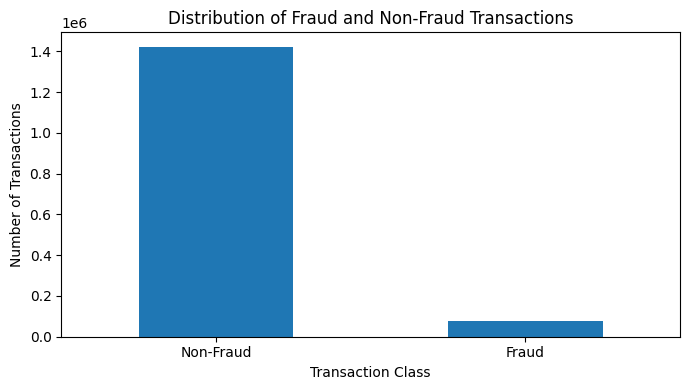

In [ ]:

# 7. Distribusi kelas target
class_counts = df["Is Fraudulent"].value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class": ["Non-Fraud", "Fraud"],
    "Label": [0, 1],
    "Count": [int(class_counts.get(0, 0)), int(class_counts.get(1, 0))],
})
class_distribution["Percentage"] = (
    class_distribution["Count"] / class_distribution["Count"].sum() * 100
)

display(class_distribution)
class_distribution.to_csv(
    RESULTS_DIR / "04_class_distribution.csv", index=False
)

ax = class_distribution.plot(
    x="Class",
    y="Count",
    kind="bar",
    legend=False,
    figsize=(7, 4),
)
ax.set_title("Distribution of Fraud and Non-Fraud Transactions")
ax.set_xlabel("Transaction Class")
ax.set_ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "01_class_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [ ]:

# 8. Statistik deskriptif dan kardinalitas
numeric_columns_original = [
    "Transaction Amount",
    "Quantity",
    "Customer Age",
    "Account Age Days",
    "Transaction Hour",
    "Is Fraudulent",
]

numeric_statistics = df[numeric_columns_original].describe().T
numeric_statistics.to_csv(RESULTS_DIR / "05_numeric_statistics.csv")
display(numeric_statistics)

categorical_columns_original = [
    "Payment Method",
    "Product Category",
    "Device Used",
    "Customer Location",
    "IP Address",
    "Shipping Address",
    "Billing Address",
    "Customer ID",
    "Transaction ID",
]

cardinality = pd.DataFrame({
    "Attribute": categorical_columns_original,
    "Unique Values": [df[col].nunique(dropna=False) for col in categorical_columns_original],
}).sort_values("Unique Values", ascending=False)

cardinality.to_csv(RESULTS_DIR / "06_attribute_cardinality.csv", index=False)
display(cardinality)

for col in ["Payment Method", "Product Category", "Device Used"]:
    summary = (
        df.groupby([col, "Is Fraudulent"], dropna=False)
          .size()
          .unstack(fill_value=0)
          .rename(columns={0: "Non-Fraud", 1: "Fraud"})
    )
    summary["Fraud Rate (%)"] = (
        summary["Fraud"] / summary[["Non-Fraud", "Fraud"]].sum(axis=1) * 100
    )
    summary.to_csv(
        RESULTS_DIR / f"category_summary_{col.replace(' ', '_').lower()}.csv"
    )
    print(f"\nSummary: {col}")
    display(summary)


,count,mean,std,min,25%,50%,75%,max
Transaction Amount,1496586.0,226.809349,270.583095,10.0,68.62,151.76,296.05,12701.75
Quantity,1496586.0,3.000235,1.414814,1.0,2.00,3.00,4.00,5.00
Customer Age,1496586.0,34.512841,10.003233,-16.0,28.00,35.00,41.00,86.00
Account Age Days,1496586.0,179.630829,106.872560,1.0,86.00,179.00,272.00,365.00
Transaction Hour,1496586.0,11.286633,6.976067,0.0,5.00,11.00,17.00,23.00
Is Fraudulent,1496586.0,0.050154,0.218263,0.0,0.00,0.00,0.00,1.00


,Attribute,Unique Values
7,Customer ID,1496586
8,Transaction ID,1496586
6,Billing Address,1496583
5,Shipping Address,1496582
4,IP Address,1496278
3,Customer Location,99412
1,Product Category,5
0,Payment Method,4
2,Device Used,3



Summary: Payment Method


Is Fraudulent,Non-Fraud,Fraud,Fraud Rate (%)
Payment Method,,,
PayPal,355080,18787,5.025049
bank transfer,355252,18886,5.047870
credit card,355738,18614,4.972326
debit card,355456,18773,5.016447



Summary: Product Category


Is Fraudulent,Non-Fraud,Fraud,Fraud Rate (%)
Product Category,,,
clothing,283947,15071,5.040165
electronics,285187,14855,4.950974
health & beauty,284973,15065,5.021031
home & garden,283508,14984,5.019900
toys & games,283911,15085,5.045218



Summary: Device Used


Is Fraudulent,Non-Fraud,Fraud,Fraud Rate (%)
Device Used,,,
desktop,473341,24853,4.988619
mobile,474328,25296,5.063007
tablet,473857,24911,4.994506



## B. Data Preparation

Tahap ini:
- membentuk fitur `Address Match`;
- mengekstrak fitur tanggal dan waktu;
- membentuk `Amount per Item`;
- menghapus atribut identitas dan atribut ber-kardinalitas sangat tinggi;
- membagi data menjadi training, validation, dan testing secara stratified;
- menerapkan frequency encoding untuk `Customer Location`;
- menerapkan one-hot encoding pada kategori rendah.


In [ ]:

# 9. Data cleaning, feature engineering, dan pemilihan atribut
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce",
)

# ---------------------------------------------------------
# A. Menangani usia pelanggan yang tidak logis
# ---------------------------------------------------------
invalid_age_mask = df["Customer Age"] < 0
invalid_age_count = int(invalid_age_mask.sum())
invalid_age_fraud = int(
    df.loc[invalid_age_mask, "Is Fraudulent"].sum()
)

print("Invalid negative ages:", invalid_age_count)
print("Fraud rows among invalid ages:", invalid_age_fraud)

# Nilai usia negatif dihapus karena tidak mungkin secara logis.
# Jumlahnya sangat kecil dibandingkan keseluruhan dataset.
df = df.loc[~invalid_age_mask].copy()

cleaning_summary = pd.DataFrame({
    "Indicator": [
        "Rows before cleaning",
        "Negative-age rows removed",
        "Fraud rows removed",
        "Rows after cleaning",
        "Percentage removed",
    ],
    "Value": [
        int(len(df) + invalid_age_count),
        invalid_age_count,
        invalid_age_fraud,
        int(len(df)),
        float(
            invalid_age_count
            / (len(df) + invalid_age_count)
            * 100
        ),
    ],
})
cleaning_summary.to_csv(
    RESULTS_DIR / "07_data_cleaning_summary.csv",
    index=False,
)
display(cleaning_summary)

# ---------------------------------------------------------
# B. Feature engineering
# ---------------------------------------------------------

# Kesesuaian alamat
df["Address Match"] = (
    df["Shipping Address"].astype(str)
    == df["Billing Address"].astype(str)
).astype("int8")

# Fitur temporal dasar
df["Transaction Month"] = (
    df["Transaction Date"].dt.month.astype("int8")
)
df["Transaction Day"] = (
    df["Transaction Date"].dt.day.astype("int8")
)
df["Transaction DayOfWeek"] = (
    df["Transaction Date"].dt.dayofweek.astype("int8")
)
df["Is Weekend"] = (
    df["Transaction DayOfWeek"] >= 5
).astype("int8")
df["Is Night Transaction"] = (
    (df["Transaction Hour"] <= 5)
    | (df["Transaction Hour"] >= 22)
).astype("int8")

# Representasi waktu siklik
df["Transaction Hour Sin"] = np.sin(
    2 * np.pi * df["Transaction Hour"] / 24
).astype("float32")
df["Transaction Hour Cos"] = np.cos(
    2 * np.pi * df["Transaction Hour"] / 24
).astype("float32")
df["DayOfWeek Sin"] = np.sin(
    2 * np.pi * df["Transaction DayOfWeek"] / 7
).astype("float32")
df["DayOfWeek Cos"] = np.cos(
    2 * np.pi * df["Transaction DayOfWeek"] / 7
).astype("float32")

# Nilai transaksi per barang
safe_quantity = df["Quantity"].replace(0, np.nan)
df["Amount per Item"] = (
    df["Transaction Amount"] / safe_quantity
).replace([np.inf, -np.inf], np.nan)

# Transformasi log untuk mengurangi kemencengan distribusi
df["Log Transaction Amount"] = np.log1p(
    df["Transaction Amount"].clip(lower=0)
).astype("float32")
df["Log Amount per Item"] = np.log1p(
    df["Amount per Item"].clip(lower=0)
).astype("float32")

# Optimasi tipe data numerik
float_columns = [
    "Transaction Amount",
    "Amount per Item",
    "Quantity",
    "Customer Age",
    "Account Age Days",
    "Transaction Hour",
]

for col in float_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce",
    ).astype("float32")

df["Is Fraudulent"] = df["Is Fraudulent"].astype("int8")

# Simpan Transaction Date untuk temporal split.
dropped_columns = [
    "Transaction ID",
    "Customer ID",
    "IP Address",
    "Shipping Address",
    "Billing Address",
]

model_df = df.drop(columns=dropped_columns).copy()
del df
gc.collect()

print("Dropped columns:", dropped_columns)
print("Modeling dataframe shape:", model_df.shape)
print("Modeling columns:")
print(model_df.columns.tolist())


Invalid negative ages: 259
Fraud rows among invalid ages: 12


,Indicator,Value
0,Rows before cleaning,1.496586e+06
1,Negative-age rows removed,2.590000e+02
2,Fraud rows removed,1.200000e+01
3,Rows after cleaning,1.496327e+06
4,Percentage removed,1.730606e-02


Dropped columns: ['Transaction ID', 'Customer ID', 'IP Address', 'Shipping Address', 'Billing Address']
Modeling dataframe shape: (1496327, 24)
Modeling columns:
['Transaction Amount', 'Transaction Date', 'Payment Method', 'Product Category', 'Quantity', 'Customer Age', 'Customer Location', 'Device Used', 'Is Fraudulent', 'Account Age Days', 'Transaction Hour', 'Address Match', 'Transaction Month', 'Transaction Day', 'Transaction DayOfWeek', 'Is Weekend', 'Is Night Transaction', 'Transaction Hour Sin', 'Transaction Hour Cos', 'DayOfWeek Sin', 'DayOfWeek Cos', 'Amount per Item', 'Log Transaction Amount', 'Log Amount per Item']


In [ ]:

# 10. Temporal splitting: training 64%, validation 16%, testing 20%
TARGET = "Is Fraudulent"

# Urutkan transaksi berdasarkan waktu
model_df = model_df.sort_values(
    "Transaction Date"
).reset_index(drop=True)

n_rows = len(model_df)
train_end = int(n_rows * 0.64)
val_end = int(n_rows * 0.80)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

def split_xy(dataframe):
    timestamps = dataframe["Transaction Date"].copy()
    y_part = dataframe[TARGET].copy()
    X_part = dataframe.drop(
        columns=[TARGET, "Transaction Date"]
    ).copy()
    return X_part, y_part, timestamps

X_train, y_train, time_train = split_xy(train_df)
X_val, y_val, time_val = split_xy(val_df)
X_test, y_test, time_test = split_xy(test_df)

del train_df, val_df, test_df, model_df
gc.collect()

split_summary = pd.DataFrame([
    {
        "Dataset": "Training",
        "Rows": len(y_train),
        "Fraud": int(y_train.sum()),
        "Non-Fraud": int((y_train == 0).sum()),
        "Fraud Percentage": float(y_train.mean() * 100),
        "Start Date": str(time_train.min()),
        "End Date": str(time_train.max()),
    },
    {
        "Dataset": "Validation",
        "Rows": len(y_val),
        "Fraud": int(y_val.sum()),
        "Non-Fraud": int((y_val == 0).sum()),
        "Fraud Percentage": float(y_val.mean() * 100),
        "Start Date": str(time_val.min()),
        "End Date": str(time_val.max()),
    },
    {
        "Dataset": "Testing",
        "Rows": len(y_test),
        "Fraud": int(y_test.sum()),
        "Non-Fraud": int((y_test == 0).sum()),
        "Fraud Percentage": float(y_test.mean() * 100),
        "Start Date": str(time_test.min()),
        "End Date": str(time_test.max()),
    },
])

display(split_summary)
split_summary.to_csv(
    RESULTS_DIR / "08_temporal_data_split_summary.csv",
    index=False,
)

print(
    "Temporal overlap check:",
    time_train.max() <= time_val.min()
    and time_val.max() <= time_test.min()
)


,Dataset,Rows,Fraud,Non-Fraud,Fraud Percentage,Start Date,End Date
0,Training,957649,48029,909620,5.015303,2024-01-01 00:00:00,2024-02-29 18:28:26
1,Validation,239412,12080,227332,5.045695,2024-02-29 18:28:27,2024-03-15 16:58:18
2,Testing,299266,14939,284327,4.991880,2024-03-15 16:58:22,2024-04-07 08:54:03


Temporal overlap check: True


In [ ]:

# 11. Frequency encoding Customer Location berdasarkan DATA TRAINING saja
location_frequency = (
    X_train["Customer Location"]
    .value_counts(normalize=True, dropna=False)
)

for dataset in [X_train, X_val, X_test]:
    dataset["Customer Location Frequency"] = (
        dataset["Customer Location"]
        .map(location_frequency)
        .fillna(0)
        .astype("float32")
    )
    dataset.drop(columns=["Customer Location"], inplace=True)

categorical_columns = [
    "Payment Method",
    "Product Category",
    "Device Used",
]

numeric_columns = [
    col for col in X_train.columns
    if col not in categorical_columns
]

print("Categorical columns:", categorical_columns)
print("Numeric columns:", numeric_columns)


Categorical columns: ['Payment Method', 'Product Category', 'Device Used']
Numeric columns: ['Transaction Amount', 'Quantity', 'Customer Age', 'Account Age Days', 'Transaction Hour', 'Address Match', 'Transaction Month', 'Transaction Day', 'Transaction DayOfWeek', 'Is Weekend', 'Is Night Transaction', 'Transaction Hour Sin', 'Transaction Hour Cos', 'DayOfWeek Sin', 'DayOfWeek Cos', 'Amount per Item', 'Log Transaction Amount', 'Log Amount per Item', 'Customer Location Frequency']


In [ ]:

# 12. Preprocessing: imputasi dan one-hot encoding
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
            dtype=np.float32,
        ),
    ),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_columns),
        ("cat", categorical_pipeline, categorical_columns),
    ],
    remainder="drop",
    sparse_threshold=1.0,
)

start = time.time()
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

del X_train, X_val, X_test
gc.collect()

print("Transformed training shape  :", X_train_t.shape)
print("Transformed validation shape:", X_val_t.shape)
print("Transformed testing shape   :", X_test_t.shape)
print("Number of final features    :", len(feature_names))
print(f"Preprocessing time: {(time.time() - start):.2f} seconds")

preparation_summary = pd.DataFrame({
    "Indicator": [
        "Training rows",
        "Validation rows",
        "Testing rows",
        "Final feature count",
        "Categorical encoding",
        "Location encoding",
        "Dropped attributes",
        "Split method",
    ],
    "Value": [
        X_train_t.shape[0],
        X_val_t.shape[0],
        X_test_t.shape[0],
        X_train_t.shape[1],
        "One-Hot Encoding",
        "Frequency Encoding",
        ", ".join(dropped_columns),
        "Temporal split",
    ],
})
preparation_summary.to_csv(
    RESULTS_DIR / "09_data_preparation_summary.csv", index=False
)
display(preparation_summary)


Transformed training shape  : (957649, 31)
Transformed validation shape: (239412, 31)
Transformed testing shape   : (299266, 31)
Number of final features    : 31
Preprocessing time: 5.02 seconds


,Indicator,Value
0,Training rows,957649
1,Validation rows,239412
2,Testing rows,299266
3,Final feature count,31
4,Categorical encoding,One-Hot Encoding
5,Location encoding,Frequency Encoding
6,Dropped attributes,"Transaction ID, Customer ID, IP Address, Shipp..."
7,Split method,Temporal split



## C. Modeling and Evaluation

Tiga model utama akan dibandingkan:

1. **Baseline XGBoost** tanpa pembobotan kelas;
2. **Weighted XGBoost** menggunakan `scale_pos_weight`;
3. **Tuned Weighted XGBoost** menggunakan randomized hyperparameter search.

Semua model dievaluasi menggunakan:
- Accuracy;
- Precision;
- Recall;
- F1-Score;
- ROC-AUC;
- PR-AUC;
- confusion matrix.


In [ ]:

# 13. Fungsi evaluasi model
def evaluate_model(model_name, model, X_eval, y_eval, threshold=0.50):
    probability = model.predict_proba(X_eval)[:, 1]
    prediction = (probability >= threshold).astype(int)

    cm = confusion_matrix(y_eval, prediction, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    result = {
        "Model": model_name,
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(y_eval, prediction),
        "Precision": precision_score(y_eval, prediction, zero_division=0),
        "Recall": recall_score(y_eval, prediction, zero_division=0),
        "F1-Score": f1_score(y_eval, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, probability),
        "PR-AUC": average_precision_score(y_eval, probability),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }
    return result, probability, prediction, cm


def show_result(result):
    display(pd.DataFrame([result]))
    print(
        f"TN={result['TN']:,} | FP={result['FP']:,} | "
        f"FN={result['FN']:,} | TP={result['TP']:,}"
    )


In [ ]:

# 14. Menghitung scale_pos_weight dari data training
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

print("Training non-fraud :", f"{negative_count:,}")
print("Training fraud     :", f"{positive_count:,}")
print("scale_pos_weight   :", scale_pos_weight)

pd.DataFrame({
    "Negative Count": [negative_count],
    "Positive Count": [positive_count],
    "scale_pos_weight": [scale_pos_weight],
}).to_csv(RESULTS_DIR / "09_scale_pos_weight.csv", index=False)


Training non-fraud : 909,620
Training fraud     : 48,029
scale_pos_weight   : 18.938974369651667


In [ ]:

# 15. Baseline XGBoost
baseline_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.0,
    reg_lambda=1.0,
    tree_method="hist",
    device=DEVICE,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50,
)

start = time.time()
baseline_model.fit(
    X_train_t,
    y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False,
)
print(f"Baseline training time: {(time.time() - start):.2f} seconds")
print("Best iteration:", baseline_model.best_iteration)

baseline_result, baseline_prob, baseline_pred, baseline_cm = evaluate_model(
    "Baseline XGBoost",
    baseline_model,
    X_test_t,
    y_test,
    threshold=0.50,
)
show_result(baseline_result)


Baseline training time: 4.97 seconds
Best iteration: 57


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Baseline XGBoost,0.5,0.955882,0.837218,0.144253,0.246103,0.815687,0.37832,283908,419,12784,2155


TN=283,908 | FP=419 | FN=12,784 | TP=2,155


In [ ]:

# 16. Weighted XGBoost
weighted_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.0,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    device=DEVICE,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50,
)

start = time.time()
weighted_model.fit(
    X_train_t,
    y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False,
)
print(f"Weighted training time: {(time.time() - start):.2f} seconds")
print("Best iteration:", weighted_model.best_iteration)

weighted_result, weighted_prob, weighted_pred, weighted_cm = evaluate_model(
    "Weighted XGBoost",
    weighted_model,
    X_test_t,
    y_test,
    threshold=0.50,
)
show_result(weighted_result)


Weighted training time: 4.44 seconds
Best iteration: 93


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Weighted XGBoost,0.5,0.779985,0.145426,0.698775,0.240749,0.815437,0.377813,222984,61343,4500,10439


TN=222,984 | FP=61,343 | FN=4,500 | TP=10,439



## D. Randomized Hyperparameter Search

Bagian ini dapat memerlukan waktu lebih lama. Untuk menjaga penggunaan RAM dan waktu komputasi, pencarian parameter menggunakan sampel stratified maksimal 300.000 data training.

Nilai `N_ITER` dapat:
- diturunkan menjadi 5 untuk uji cepat;
- dinaikkan menjadi 15–20 untuk pencarian yang lebih luas.


In [ ]:

# 17. Menyiapkan sampel tuning
MAX_TUNE_ROWS = 500_000
N_ITER = 30

if X_train_t.shape[0] > MAX_TUNE_ROWS:
    tune_size = MAX_TUNE_ROWS / X_train_t.shape[0]
    _, X_tune, _, y_tune = train_test_split(
        X_train_t,
        y_train,
        test_size=tune_size,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
else:
    X_tune = X_train_t
    y_tune = y_train

print("Tuning sample shape:", X_tune.shape)
print("Tuning fraud rate  :", float(y_tune.mean()))
print("Number of tested combinations:", N_ITER)


Tuning sample shape: (500000, 31)
Tuning fraud rate  : 0.050154
Number of tested combinations: 30


In [ ]:

# 18. Randomized hyperparameter search berdasarkan validation PR-AUC
parameter_space = {
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "min_child_weight": [1, 3, 5, 8, 10, 15],
    "subsample": [0.65, 0.70, 0.80, 0.90, 1.00],
    "colsample_bytree": [0.60, 0.70, 0.80, 0.90, 1.00],
    "gamma": [0.0, 0.1, 0.3, 0.5, 1.0],
    "reg_alpha": [0.0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0, 20.0],
    "max_delta_step": [0, 1, 3, 5],
    "scale_pos_weight": [
        1.0,
        scale_pos_weight * 0.50,
        scale_pos_weight * 0.75,
        scale_pos_weight,
        scale_pos_weight * 1.25,
    ],
}

sampled_parameters = list(
    ParameterSampler(
        parameter_space,
        n_iter=N_ITER,
        random_state=RANDOM_STATE,
    )
)

search_records = []
best_validation_pr_auc = -np.inf
best_parameters = None

for index, parameters in enumerate(
    sampled_parameters,
    start=1,
):
    print(
        f"Combination {index}/{N_ITER}: "
        f"{parameters}"
    )

    candidate = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=1800,
        tree_method="hist",
        device=DEVICE,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=60,
        **parameters,
    )

    start = time.time()
    candidate.fit(
        X_tune,
        y_tune,
        eval_set=[(X_val_t, y_val)],
        verbose=False,
    )

    validation_probability = (
        candidate.predict_proba(X_val_t)[:, 1]
    )
    validation_pr_auc = average_precision_score(
        y_val,
        validation_probability,
    )
    validation_roc_auc = roc_auc_score(
        y_val,
        validation_probability,
    )

    record = {
        "Combination": index,
        **parameters,
        "Best Iteration": candidate.best_iteration,
        "Validation PR-AUC": validation_pr_auc,
        "Validation ROC-AUC": validation_roc_auc,
        "Training Seconds": time.time() - start,
    }
    search_records.append(record)

    print(
        f"Validation PR-AUC={validation_pr_auc:.6f} | "
        f"ROC-AUC={validation_roc_auc:.6f}\n"
    )

    if validation_pr_auc > best_validation_pr_auc:
        best_validation_pr_auc = validation_pr_auc
        best_parameters = parameters.copy()

search_results = pd.DataFrame(
    search_records
).sort_values(
    "Validation PR-AUC",
    ascending=False,
)
search_results.to_csv(
    RESULTS_DIR / "11_random_search_results.csv",
    index=False,
)

print("BEST PARAMETERS")
print(json.dumps(best_parameters, indent=2))
print(
    "Best validation PR-AUC:",
    best_validation_pr_auc,
)
display(search_results.head(10))


Combination 1/30: {'subsample': 0.9, 'scale_pos_weight': 14.20423077723875, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'min_child_weight': 15, 'max_depth': 5, 'max_delta_step': 1, 'learning_rate': 0.02, 'gamma': 1.0, 'colsample_bytree': 0.8}
Validation PR-AUC=0.382690 | ROC-AUC=0.817253

Combination 2/30: {'subsample': 1.0, 'scale_pos_weight': 9.469487184825834, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'min_child_weight': 15, 'max_depth': 3, 'max_delta_step': 5, 'learning_rate': 0.03, 'gamma': 1.0, 'colsample_bytree': 0.8}
Validation PR-AUC=0.382684 | ROC-AUC=0.817208

Combination 3/30: {'subsample': 0.7, 'scale_pos_weight': 1.0, 'reg_lambda': 20.0, 'reg_alpha': 0.0, 'min_child_weight': 5, 'max_depth': 3, 'max_delta_step': 0, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 1.0}
Validation PR-AUC=0.382983 | ROC-AUC=0.817883

Combination 4/30: {'subsample': 0.8, 'scale_pos_weight': 23.673717962064586, 'reg_lambda': 5.0, 'reg_alpha': 0.01, 'min_child_weight': 15, 'max_depth': 4, 'max_delta

,Combination,subsample,scale_pos_weight,reg_lambda,reg_alpha,min_child_weight,max_depth,max_delta_step,learning_rate,gamma,colsample_bytree,Best Iteration,Validation PR-AUC,Validation ROC-AUC,Training Seconds
3,4,0.80,23.673718,5.0,0.01,15,4,5,0.03,1.0,0.7,161,0.383161,0.817497,3.468682
18,19,0.70,1.000000,20.0,0.10,1,3,0,0.03,0.0,1.0,150,0.383090,0.817827,4.417905
2,3,0.70,1.000000,20.0,0.00,5,3,0,0.03,0.3,1.0,148,0.382983,0.817883,4.233182
25,26,0.70,18.938974,5.0,1.00,5,4,5,0.05,0.3,0.8,102,0.382982,0.817475,2.802292
13,14,0.65,9.469487,1.0,0.10,5,5,1,0.01,0.1,0.8,397,0.382967,0.817607,4.523327
4,5,1.00,14.204231,20.0,0.00,15,4,5,0.08,1.0,0.6,64,0.382895,0.817180,2.567406
6,7,0.80,9.469487,5.0,0.10,15,4,5,0.01,0.1,1.0,519,0.382886,0.817645,5.731014
7,8,0.80,14.204231,10.0,0.50,1,4,0,0.01,0.1,0.9,419,0.382865,0.817738,3.883992
20,21,0.80,1.000000,1.0,0.10,10,3,0,0.08,0.3,0.6,167,0.382835,0.817332,2.790946
0,1,0.90,14.204231,1.0,0.10,15,5,1,0.02,1.0,0.8,190,0.382690,0.817253,3.236868


In [ ]:

# 19. Melatih tuned model pada seluruh data training
tuned_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=1500,
    tree_method="hist",
    device=DEVICE,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50,
    **best_parameters,
)

start = time.time()
tuned_model.fit(
    X_train_t,
    y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False,
)
print(f"Tuned model training time: {(time.time() - start):.2f} seconds")
print("Best iteration:", tuned_model.best_iteration)

tuned_result_050, tuned_prob_test, tuned_pred_050, tuned_cm_050 = evaluate_model(
    "Tuned Weighted XGBoost (Threshold 0.50)",
    tuned_model,
    X_test_t,
    y_test,
    threshold=0.50,
)
show_result(tuned_result_050)


Tuned model training time: 5.23 seconds
Best iteration: 365


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Tuned Weighted XGBoost (Threshold 0.50),0.5,0.706846,0.120922,0.77716,0.209282,0.815384,0.378686,199925,84402,3329,11610


TN=199,925 | FP=84,402 | FN=3,329 | TP=11,610


In [ ]:

# 20. Menentukan kebijakan threshold dari DATA VALIDATION
validation_probability = tuned_model.predict_proba(
    X_val_t
)[:, 1]

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_val,
        validation_probability,
    )
)

precision_t = precision_values[:-1]
recall_t = recall_values[:-1]

f1_values = (
    2 * precision_t * recall_t
    / (precision_t + recall_t + 1e-12)
)

# A. Threshold dengan F1-Score terbaik
best_f1_index = int(np.nanargmax(f1_values))
best_f1_threshold = float(
    thresholds[best_f1_index]
)

# B. Threshold dengan target recall minimal 70%.
# Di antara threshold yang memenuhi target, pilih
# precision tertinggi.
target_recall = 0.70
eligible = np.where(recall_t >= target_recall)[0]

if len(eligible) > 0:
    high_recall_index = eligible[
        np.argmax(precision_t[eligible])
    ]
else:
    high_recall_index = int(
        np.nanargmax(recall_t)
    )

high_recall_threshold = float(
    thresholds[high_recall_index]
)

threshold_summary = pd.DataFrame([
    {
        "Policy": "Best Validation F1",
        "Threshold": best_f1_threshold,
        "Validation Precision": precision_t[best_f1_index],
        "Validation Recall": recall_t[best_f1_index],
        "Validation F1-Score": f1_values[best_f1_index],
    },
    {
        "Policy": "Target Recall >= 70%",
        "Threshold": high_recall_threshold,
        "Validation Precision": precision_t[high_recall_index],
        "Validation Recall": recall_t[high_recall_index],
        "Validation F1-Score": f1_values[high_recall_index],
    },
])

display(threshold_summary)
threshold_summary.to_csv(
    RESULTS_DIR / "12_threshold_policies.csv",
    index=False,
)

tuned_result_f1, tuned_prob_f1, tuned_pred_f1, tuned_cm_f1 = (
    evaluate_model(
        "Tuned XGBoost (Best-F1 Threshold)",
        tuned_model,
        X_test_t,
        y_test,
        threshold=best_f1_threshold,
    )
)

tuned_result_recall, tuned_prob_recall, tuned_pred_recall, tuned_cm_recall = (
    evaluate_model(
        "Tuned XGBoost (Recall-Target Threshold)",
        tuned_model,
        X_test_t,
        y_test,
        threshold=high_recall_threshold,
    )
)

print("\nTEST RESULT — BEST F1 POLICY")
show_result(tuned_result_f1)

print("\nTEST RESULT — HIGH RECALL POLICY")
show_result(tuned_result_recall)

with open(
    RESULTS_DIR / "best_thresholds.json",
    "w",
) as f:
    json.dump(
        {
            "best_f1_threshold": best_f1_threshold,
            "high_recall_threshold": high_recall_threshold,
            "target_recall": target_recall,
        },
        f,
        indent=2,
    )


,Policy,Threshold,Validation Precision,Validation Recall,Validation F1-Score
0,Best Validation F1,0.847997,0.422122,0.388576,0.404655
1,Target Recall >= 70%,0.558414,0.149892,0.700000,0.246912



TEST RESULT — BEST F1 POLICY


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Tuned XGBoost (Best-F1 Threshold),0.847997,0.941046,0.404963,0.385635,0.395063,0.815384,0.378686,275862,8465,9178,5761


TN=275,862 | FP=8,465 | FN=9,178 | TP=5,761

TEST RESULT — HIGH RECALL POLICY


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Tuned XGBoost (Recall-Target Threshold),0.558414,0.786872,0.148788,0.69255,0.244951,0.815384,0.378686,225138,59189,4593,10346


TN=225,138 | FP=59,189 | FN=4,593 | TP=10,346


In [ ]:

# 21. Tabel perbandingan model dan kebijakan threshold
model_comparison = pd.DataFrame([
    baseline_result,
    weighted_result,
    tuned_result_050,
    tuned_result_f1,
    tuned_result_recall,
])

metric_order = [
    "Model",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC",
    "TN",
    "FP",
    "FN",
    "TP",
]
model_comparison = model_comparison[metric_order]
model_comparison.to_csv(
    RESULTS_DIR / "13_model_comparison.csv",
    index=False,
)

display(
    model_comparison.style.format({
        "Threshold": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}",
    })
)


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Baseline XGBoost,0.5000,0.9559,0.8372,0.1443,0.2461,0.8157,0.3783,283908,419,12784,2155
1,Weighted XGBoost,0.5000,0.7800,0.1454,0.6988,0.2407,0.8154,0.3778,222984,61343,4500,10439
2,Tuned Weighted XGBoost (Threshold 0.50),0.5000,0.7068,0.1209,0.7772,0.2093,0.8154,0.3787,199925,84402,3329,11610
3,Tuned XGBoost (Best-F1 Threshold),0.8480,0.9410,0.4050,0.3856,0.3951,0.8154,0.3787,275862,8465,9178,5761
4,Tuned XGBoost (Recall-Target Threshold),0.5584,0.7869,0.1488,0.6925,0.2450,0.8154,0.3787,225138,59189,4593,10346



## E. Confusion Matrix, ROC Curve, PR Curve, and Feature Importance

Gambar di bagian ini akan digunakan dalam **Results & Discussion**.


,Predicted Non-Fraud,Predicted Fraud
Actual Non-Fraud,275862,8465
Actual Fraud,9178,5761


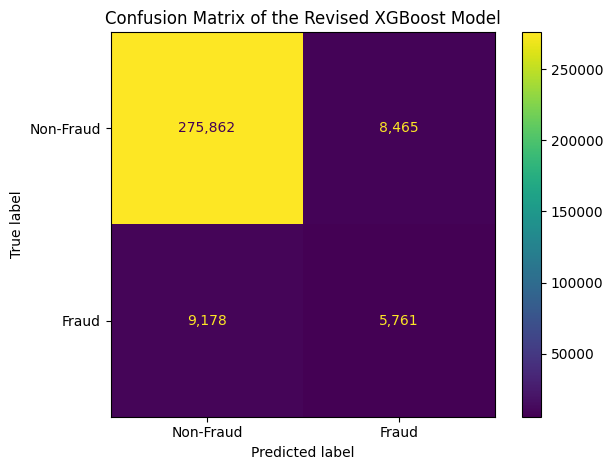

In [ ]:

# 22. Confusion matrix model utama:
# tuned XGBoost dengan Best-F1 Threshold
best_model_name = tuned_result_f1["Model"]
best_confusion_matrix = tuned_cm_f1

confusion_table = pd.DataFrame(
    best_confusion_matrix,
    index=[
        "Actual Non-Fraud",
        "Actual Fraud",
    ],
    columns=[
        "Predicted Non-Fraud",
        "Predicted Fraud",
    ],
)
confusion_table.to_csv(
    RESULTS_DIR / "14_best_confusion_matrix.csv"
)
display(confusion_table)

disp = ConfusionMatrixDisplay(
    confusion_matrix=best_confusion_matrix,
    display_labels=["Non-Fraud", "Fraud"],
)
disp.plot(values_format=",d")
plt.title(
    "Confusion Matrix of the Revised XGBoost Model"
)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR
    / "02_confusion_matrix_revised_model.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


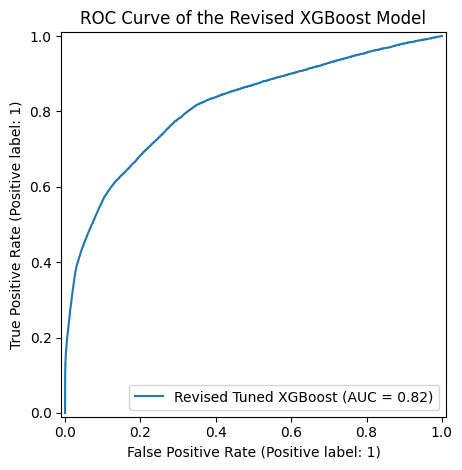

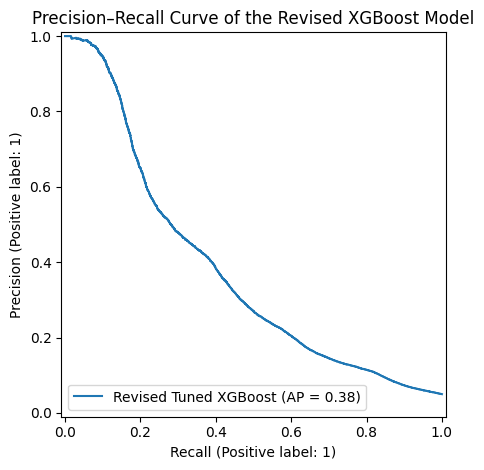

In [ ]:

# 23. ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    tuned_prob_f1,
    name="Revised Tuned XGBoost",
)
plt.title("ROC Curve of the Revised XGBoost Model")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "03_roc_curve_revised_model.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# 24. Precision–Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    tuned_prob_f1,
    name="Revised Tuned XGBoost",
)
plt.title(
    "Precision–Recall Curve of the Revised XGBoost Model"
)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR
    / "04_precision_recall_curve_revised_model.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


,Feature,Importance
3,num__Account Age Days,0.398790
10,num__Is Night Transaction,0.184224
4,num__Transaction Hour,0.121797
16,num__Log Transaction Amount,0.075676
0,num__Transaction Amount,0.073682
11,num__Transaction Hour Sin,0.039200
12,num__Transaction Hour Cos,0.018664
15,num__Amount per Item,0.017849
1,num__Quantity,0.005143
24,cat__Product Category_electronics,0.003488


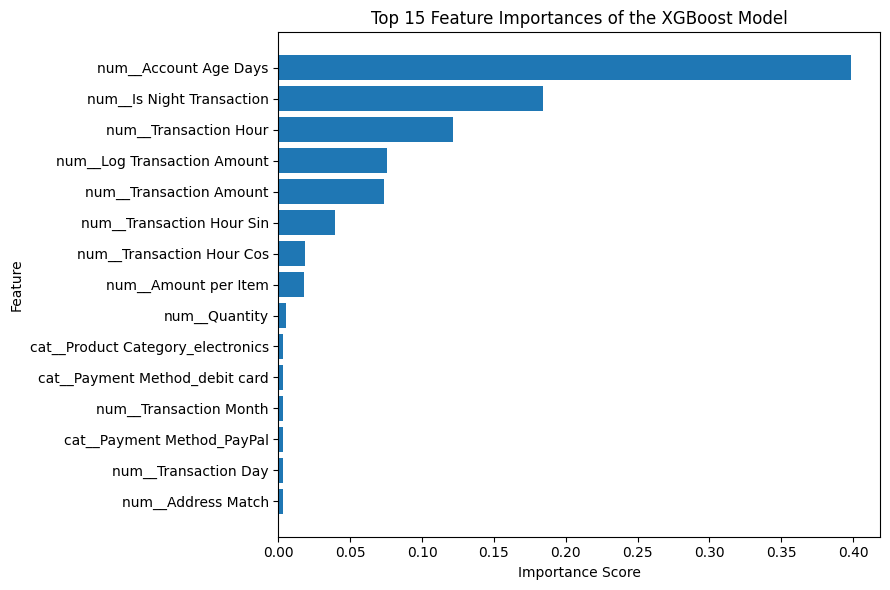

In [ ]:

# 25. Feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tuned_model.feature_importances_,
}).sort_values("Importance", ascending=False)

importance_df.to_csv(
    RESULTS_DIR / "15_feature_importance_all.csv", index=False
)

top_15_importance = importance_df.head(15).copy()
top_15_importance.to_csv(
    RESULTS_DIR / "16_feature_importance_top15.csv", index=False
)
display(top_15_importance)

plot_data = top_15_importance.sort_values("Importance", ascending=True)
plt.figure(figsize=(9, 6))
plt.barh(plot_data["Feature"], plot_data["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances of the XGBoost Model")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "05_feature_importance_revised_top15.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [ ]:

# 26. Classification report model terbaik
best_classification_report = classification_report(
    y_test,
    tuned_pred_f1,
    target_names=["Non-Fraud", "Fraud"],
    output_dict=True,
    zero_division=0,
)

classification_report_df = pd.DataFrame(
    best_classification_report
).T
classification_report_df.to_csv(
    RESULTS_DIR / "17_classification_report_revised_model.csv"
)
display(classification_report_df)


,precision,recall,f1-score,support
Non-Fraud,0.967801,0.970228,0.969013,284327.000000
Fraud,0.404963,0.385635,0.395063,14939.000000
accuracy,0.941046,0.941046,0.941046,0.941046
macro avg,0.686382,0.677931,0.682038,299266.000000
weighted avg,0.939705,0.941046,0.940362,299266.000000



## F. Deployment Output

Model, preprocessor, location-frequency mapping, dan threshold disimpan agar dapat digunakan kembali.


In [ ]:

# 27. Menyimpan model dan komponen preprocessing
tuned_model.save_model(
    str(
        RESULTS_DIR
        / "xgboost_fraud_model_revised.json"
    )
)
joblib.dump(
    preprocessor,
    RESULTS_DIR / "preprocessor_revised.joblib",
)
joblib.dump(
    location_frequency,
    RESULTS_DIR
    / "customer_location_frequency_revised.joblib",
)

metadata = {
    "target": TARGET,
    "split_method": "temporal_64_16_20",
    "invalid_negative_ages_removed": invalid_age_count,
    "best_f1_threshold": best_f1_threshold,
    "high_recall_threshold": high_recall_threshold,
    "best_parameters": best_parameters,
    "feature_count": int(len(feature_names)),
    "training_rows": int(len(y_train)),
    "validation_rows": int(len(y_val)),
    "testing_rows": int(len(y_test)),
    "scale_pos_weight": float(scale_pos_weight),
    "device": DEVICE,
    "xgboost_version": xgb.__version__,
}

with open(
    RESULTS_DIR / "model_metadata_revised.json",
    "w",
) as f:
    json.dump(metadata, f, indent=2)

print(
    "Model dan preprocessing revisi "
    "berhasil disimpan."
)


Model dan preprocessing revisi berhasil disimpan.


In [ ]:

# 28. Ringkasan output untuk IV. RESULTS & DISCUSSION
print("=" * 78)
print("REVISED RESULTS FOR IV. RESULTS & DISCUSSION")
print("=" * 78)

print("\n1. DATA CLEANING")
print(cleaning_summary.to_string(index=False))

print("\n2. TEMPORAL DATA SPLIT")
print(split_summary.to_string(index=False))

print("\n3. SCALE POS WEIGHT")
print(scale_pos_weight)

print("\n4. BEST HYPERPARAMETERS")
print(json.dumps(best_parameters, indent=2))

print("\n5. THRESHOLD POLICIES")
print(threshold_summary.to_string(index=False))

print("\n6. MODEL COMPARISON")
print(model_comparison.to_string(index=False))

print("\n7. PRIMARY CONFUSION MATRIX")
print(confusion_table)

print("\n8. TOP 15 FEATURE IMPORTANCE")
print(top_15_importance.to_string(index=False))

print("\nSemua file disimpan di:", RESULTS_DIR)


REVISED RESULTS FOR IV. RESULTS & DISCUSSION

1. DATA CLEANING
                Indicator        Value
     Rows before cleaning 1.496586e+06
Negative-age rows removed 2.590000e+02
       Fraud rows removed 1.200000e+01
      Rows after cleaning 1.496327e+06
       Percentage removed 1.730606e-02

2. TEMPORAL DATA SPLIT
   Dataset   Rows  Fraud  Non-Fraud  Fraud Percentage          Start Date            End Date
  Training 957649  48029     909620          5.015303 2024-01-01 00:00:00 2024-02-29 18:28:26
Validation 239412  12080     227332          5.045695 2024-02-29 18:28:27 2024-03-15 16:58:18
   Testing 299266  14939     284327          4.991880 2024-03-15 16:58:22 2024-04-07 08:54:03

3. SCALE POS WEIGHT
18.938974369651667

4. BEST HYPERPARAMETERS
{
  "subsample": 0.8,
  "scale_pos_weight": 23.673717962064586,
  "reg_lambda": 5.0,
  "reg_alpha": 0.01,
  "min_child_weight": 15,
  "max_depth": 4,
  "max_delta_step": 5,
  "learning_rate": 0.03,
  "gamma": 1.0,
  "colsample_bytree": 0.

In [ ]:

# 29. Membuat ZIP hasil revisi dan mengunduhnya
archive_path = shutil.make_archive(
    "/content/fraud_results_revised",
    "zip",
    RESULTS_DIR,
)
print("ZIP dibuat:", archive_path)

from google.colab import files
files.download(archive_path)


ZIP dibuat: /content/fraud_results_revised.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## File yang perlu dikirim kembali

Setelah seluruh sel selesai, kirimkan:

**`fraud_results_revised.zip`**

File tersebut berisi hasil yang sudah diperbaiki melalui:
- penghapusan usia negatif;
- temporal split;
- feature engineering tambahan;
- hyperparameter tuning yang lebih luas;
- dua kebijakan threshold.
